In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike_timemax  # TIME-MAXIMIZED VERSION
# import modeselectoralt
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 3/12     # Total time
print(f"Using dt = {dt} seconds, T = {T} years")

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

# NOTE: change verbose argument for debugging
# Using n-indexed mode selection
loglike_obj = loglike_timemax.LogLikeTimeMax(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")


def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        log_likes[i] = loglike #NOTE: scaled 10x

    return log_likes

def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8,1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others 

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    
    return transformed

    

print('Done setting up log-likelihood and prior.')

Using dt = 10 seconds, T = 0.25 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Calculating SNR...
SNR calculated: 5.942134448355127
Setting up log_density and prior functions...
Done setting up log-likelihood and prior.


In [ ]:
sampler = parismc.Sampler.load_state('./search/intrinsic_ffunc_3mth_snr32_run3/sampler_state.pkl')

In [ ]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [4]:
sampler.inv_covariances_list

[array([[[ 1.00000000e+10,  0.00000000e+00,  0.00000000e+00,
           0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  1.00000000e+10,  0.00000000e+00,
           0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+10,
           0.00000000e+00,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
           1.00000000e+10,  0.00000000e+00],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
           0.00000000e+00,  1.00000000e+10]],
 
        [[ 6.64361995e+08,  3.29709618e+08,  1.36919605e+08,
           4.15726469e+07,  8.14578172e+07],
         [ 3.29709618e+08,  8.79170003e+08,  1.13165760e+08,
          -1.14048778e+08,  3.82974185e+08],
         [ 1.36919605e+08,  1.13165760e+08,  5.82027135e+08,
          -3.04497530e+08,  2.46116646e+08],
         [ 4.15726469e+07, -1.14048778e+08, -3.04497530e+08,
           1.67538857e+09, -3.94806716e+08],
         [ 8.14578172e+07,  3.82974185e+08,

In [5]:
sampler.inv_covariances_list[0]

array([[[ 1.00000000e+10,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  1.00000000e+10,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+10,
          0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          1.00000000e+10,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  1.00000000e+10]],

       [[ 6.64361995e+08,  3.29709618e+08,  1.36919605e+08,
          4.15726469e+07,  8.14578172e+07],
        [ 3.29709618e+08,  8.79170003e+08,  1.13165760e+08,
         -1.14048778e+08,  3.82974185e+08],
        [ 1.36919605e+08,  1.13165760e+08,  5.82027135e+08,
         -3.04497530e+08,  2.46116646e+08],
        [ 4.15726469e+07, -1.14048778e+08, -3.04497530e+08,
          1.67538857e+09, -3.94806716e+08],
        [ 8.14578172e+07,  3.82974185e+08,  2.46116646e+08,
  

In [6]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[ 0.460015  ,  0.45275167,  0.46970832,  0.53074169,  0.64751834],
        [ 0.46000763,  0.4527654 ,  0.46972023,  0.53073865,  0.64752171],
        [ 0.46001589,  0.45274951,  0.4697012 ,  0.53073308,  0.64750361],
        ...,
        [ 0.29940894,  0.57016042,  0.9295042 , -0.29139331, -0.32483685],
        [ 0.23610649,  0.46013903, -0.2052673 ,  0.53331221, -0.19884556],
        [-0.50918757,  0.49646231, -1.11149906,  0.63115437, -0.32740907]],
       shape=(100000, 5))]

In [7]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([1.63139278, 1.61267667, 1.62298524, ...,       -inf,       -inf,
              -inf], shape=(100000,))]

In [ ]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))

# maxld_pt2 = prior_transform(proc_pt[1][np.argmax(logden_list)].reshape(1, -1))
# maxld_pt3 = prior_transform(proc_pt[2][np.argmax(logden_list)].reshape(1, -1))
# maxld_pt4 = prior_transform(proc_pt[3][np.argmax(logden_list)].reshape(1, -1))


In [9]:
maxld_pt1

array([[5.97800849, 1.06132813, 0.59586799, 9.62228753, 0.36892448]])

In [10]:
log_density(maxld_pt1)

array([3.22728675])

In [ ]:
logm1_pt, logm2_pt, a_pt, p0_pt, e0_pt = maxld_pt1[0]

h_pt1 = waveform_gen_comb(
    10**logm1_pt, 10**logm2_pt, a_pt, p0_pt, e0_pt,
    xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
    dt=dt, T=T
)

In [12]:
gwf.rhostat(h_pt1)

array(5.70160971)

In [13]:
gwf.Xstat_timemax(data, h_pt1), gwf.Xstat(data, h_pt1)

(array(3.76274638), array(0.00345823))

In [14]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5)
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

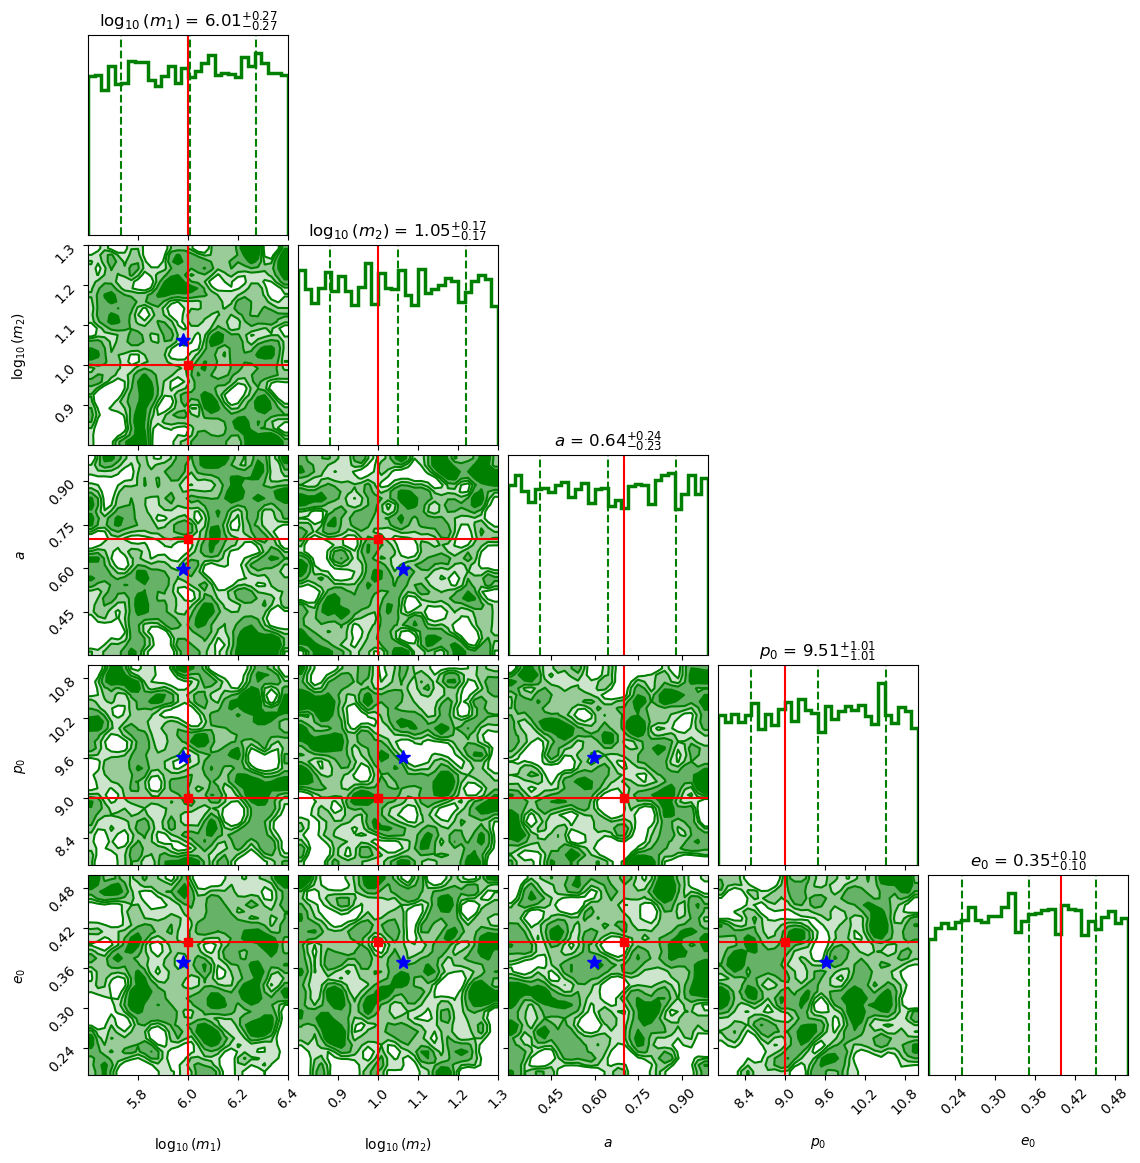

In [ ]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




# connection plot

In [ ]:
groups = [
    [(2,-2,-1),(2,-1,-1),  (2,0,-1), (2,1,-1), (2,2,-1)],#0
    [(2,-2,0),(2,-1,0),  (2,0,0), (2,1,0), (2,2,0)],#1
    [(2,-2,1),(2,-1,1),  (2,0,1), (2,1,1), (2,2,1)],#2
    [(2,-2,2),(2,-1,2),  (2,0,2), (2,1,2), (2,2,2)],#3
    [(2,-2,3),(2,-1,3),  (2,0,3), (2,1,3), (2,2,3)],#4
    [(2,-2,4),(2,-1,4),  (2,0,4), (2,1,4), (2,2,4)],#5
    [(2,-2,5),(2,-1,5),  (2,0,5), (2,1,5), (2,2,5)],#6
]

In [ ]:
proc1_maxld_pt = maxld_pt1.copy()


In [ ]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
# n_points = 50
# t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
# line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]

#NOTE: extended plots till it hits prior boundaries

prior_lo = np.array([r[0] for r in param_ranges])
prior_hi = np.array([r[1] for r in param_ranges])

start = proc1_maxld_pt_1d
direction = true_pt - proc1_maxld_pt_1d
#iterate thru each dim
t_lows, t_highs = [], []
for i in range(len(start)):
    if direction[i] > 0:
        t_lows.append((prior_lo[i] - start[i]) / direction[i])
        t_highs.append((prior_hi[i] - start[i]) / direction[i])
    elif direction[i] < 0:
        t_lows.append((prior_hi[i] - start[i]) / direction[i])
        t_highs.append((prior_lo[i] - start[i]) / direction[i])
    else:
        t_lows.append(-np.inf)
        t_highs.append(np.inf)

t_min = max(t_lows)   # most restrictive lower bound
t_max = min(t_highs)  # most restrictive upper bound

n_points = 50
t_values = np.sort(np.append(np.linspace(t_min, t_max, n_points), [0.0, 1.0]))

line_points_proc1 = start[:, np.newaxis] + t_values * direction[:, np.newaxis]


In [ ]:
def make_log_density(T_val):
    gwf_T = GWfuncs.GravWaveAnalysis(T_val, dt)
    loglike_T = loglike_timemax.LogLikeTimeMax(
        params_star, waveform_gen_comb, gwf_T,
        verbose=False, waveform_gen_sep=waveform_gen_sep,
        ell=ell, n_vals=n_vals, M_mode=None)
    
    print(f"T={T_val:.4f}yr  SNR={gwf_T.rhostat(loglike_T.signal):.3f}")

    def log_density_T(params):
        params = np.asarray(params)
        n_samples = params.shape[0]
        log_likes = np.zeros(n_samples)
        for i in range(n_samples):
            logm1, logm2, a, p0, e0 = params[i]
            log_likes[i] = loglike_T(np.array([
                10**logm1, 10**logm2, a, p0, e0,
                xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0
            ]))
        return log_likes

    return log_density_T

In [20]:
make_log_density(1/12)(maxld_pt1)

T=0.0833yr  SNR=3.330


array([1.08708399])

In [21]:
make_log_density(3/12)(maxld_pt1)

T=0.2500yr  SNR=5.942


array([3.22728675])

In [22]:
make_log_density(6/12)(maxld_pt1)

T=0.5000yr  SNR=8.808


array([0.96108634])

In [23]:
make_log_density(12/12)(maxld_pt1)

T=1.0000yr  SNR=14.081


array([0.16807893])

In [24]:
make_log_density(2)(maxld_pt1)

T=2.0000yr  SNR=32.866


array([0.01709666])

In [26]:
T_vals = [1/12, 3/12, 6/12, 12/12, 24/12]  # 1, 3, 6, 12 months
colors = ['purple', 'blue', 'green', 'red', 'orange']

log_density_funcs = {T_val: make_log_density(T_val) for T_val in T_vals}


T=0.0833yr  SNR=3.330
T=0.2500yr  SNR=5.942
T=0.5000yr  SNR=8.808
T=1.0000yr  SNR=14.081
T=2.0000yr  SNR=32.866


In [27]:
for T_val in T_vals:
    gwf_T = GWfuncs.GravWaveAnalysis(T_val, dt)
    loglike_T = loglike_timemax.LogLikeTimeMax(
        params_star, waveform_gen_comb, gwf_T,
        verbose=False, waveform_gen_sep=waveform_gen_sep,
        ell=ell, n_vals=n_vals, M_mode=None)
    snr = gwf_T.rhostat(loglike_T.signal)
    fstat_true = loglike_T(np.array([m1, m2, a, p0, e0,
                           xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
    print(f"T={T_val*12:.0f}mth  SNR={snr:.3f}  fstat_true={fstat_true:.4f}  expected~SNR={snr:.3f}")


T=1mth  SNR=3.330  fstat_true=3.3201  expected~SNR=3.330
T=3mth  SNR=5.942  fstat_true=5.9071  expected~SNR=5.942
T=6mth  SNR=8.808  fstat_true=8.7350  expected~SNR=8.808
T=12mth  SNR=14.081  fstat_true=13.9345  expected~SNR=14.081
T=24mth  SNR=32.866  fstat_true=32.3370  expected~SNR=32.866


In [28]:

logden_per_T = {}
for T_val in T_vals:
    ld_func = make_log_density(T_val)
    logden_per_T[T_val] = ld_func(line_points_proc1.T)


T=0.0833yr  SNR=3.330
T=0.2500yr  SNR=5.942
T=0.5000yr  SNR=8.808
T=1.0000yr  SNR=14.081
T=2.0000yr  SNR=32.866


In [30]:
logden_per_T

{0.08333333333333333: array([0.00602316, 0.00604457, 0.00768142, 0.00729094, 0.00889057,
        0.00856473, 0.01013164, 0.01133727, 0.01397278, 0.01815601,
        0.02347409, 0.03351875, 0.05080267, 0.07958579, 0.12562468,
        0.18809162, 0.25720827, 0.34642871, 0.44456904, 0.55708714,
        0.68626651, 0.83273692, 1.00167811, 1.08708399, 1.18204316,
        1.38126067, 1.60068023, 1.82766257, 2.0637653 , 2.29724581,
        2.53753067, 2.76329856, 2.98614523, 3.19141098, 3.32010022,
        3.24413535, 3.0426334 , 2.79438908, 2.52052933, 2.22599109,
        1.92679701, 1.62447074, 1.34138452, 1.07598553, 0.835705  ,
        0.62051446, 0.4295292 , 0.26108208, 0.12422744, 0.04603861,
        0.02141985, 0.01266722]),
 0.25: array([0.22690022, 0.23804583, 0.26599686, 0.30210047, 0.33906905,
        0.3736986 , 0.40426775, 0.45512185, 0.48364474, 0.53700257,
        0.63160613, 0.73733475, 0.8993149 , 1.10429244, 1.31622408,
        1.54881528, 1.71933714, 1.84724304, 2.24391505,

In [33]:
colors = ['purple', 'blue', 'green', 'red', 'orange']


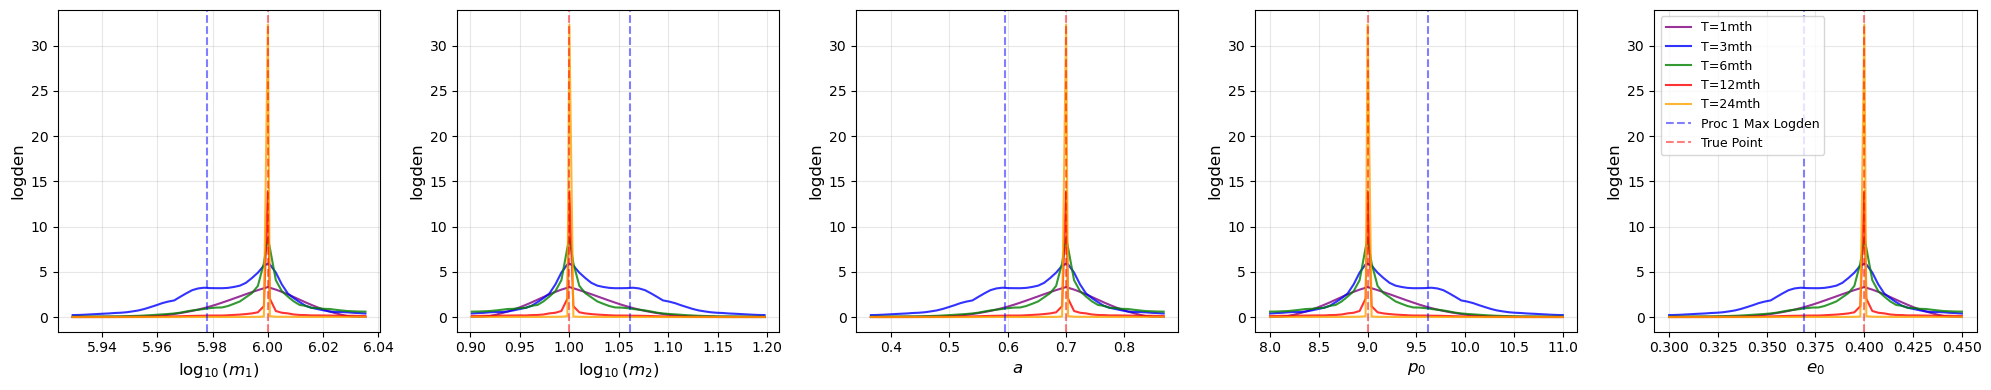

In [34]:
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
fig, axs = plt.subplots(1, 5, figsize=(20, 4))

for dim in range(5):
    ax = axs[dim]
    for T_val, color in zip(T_vals, colors):
        ax.plot(line_points_proc1[dim], logden_per_T[T_val], '-',
                color=color, alpha=0.8, linewidth=1.5, label=f'T={T_val*12:.0f}mth')
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', alpha=0.5, label='Proc 1 Max Logden')
    ax.axvline(param_true[dim],        color='red',  linestyle='--', alpha=0.5, label='True Point')
    ax.set_xlabel(labels[dim], fontsize=12)
    ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

axs[-1].legend(fontsize=9)
plt.tight_layout()

In [36]:
gwf_per_T = {T_val: GWfuncs.GravWaveAnalysis(T_val, dt) for T_val in T_vals}


In [37]:
X_proc1_per_T = {}
for T_val in T_vals:
    gwf_T = gwf_per_T[T_val]
    data_T = waveform_gen_comb(*params_star, dt=dt, T=T_val)
    
    X_list = []
    for point in line_points_proc1.T:
        logm1, logm2, a_pt, p0_pt, e0_pt = point
        try:
            template = waveform_gen_comb(
                10**logm1, 10**logm2, a_pt, p0_pt, e0_pt,
                xI0, dist, qS, phiS, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0,
                dt=dt, T=T_val)
            X = gwf_T.Xstat_timemax(data_T, template)
            X_list.append(float(X.get()) if hasattr(X, 'get') else float(X))
        except Exception:
            X_list.append(np.nan)
    
    X_proc1_per_T[T_val] = np.array(X_list)
    print(f"T={T_val*12:.0f}mth done")

T=1mth done
T=3mth done
T=6mth done
T=12mth done
T=24mth done


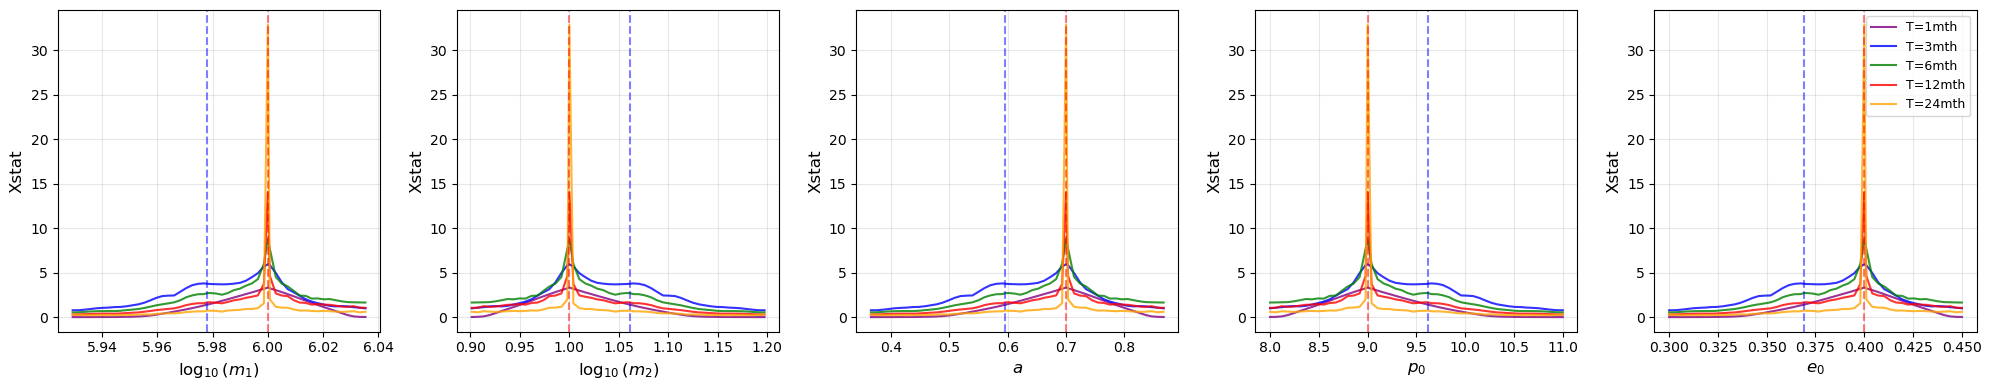

In [38]:
fig, axs = plt.subplots(1, 5, figsize=(20, 4))
for dim in range(5):
    ax = axs[dim]
    for T_val, color in zip(T_vals, colors):
        ax.plot(line_points_proc1[dim], X_proc1_per_T[T_val], '-',
                color=color, linewidth=1.5, alpha=0.8, label=f'T={T_val*12:.0f}mth')
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', alpha=0.5)
    ax.axvline(param_true[dim],        color='red',  linestyle='--', alpha=0.5)
    ax.set_xlabel(labels[dim], fontsize=12)
    ax.set_ylabel('Xstat', fontsize=12)
    ax.grid(True, alpha=0.3)
axs[-1].legend(fontsize=9)
plt.tight_layout()

In [40]:
chi2_per_T = {}

for T_val in T_vals:
    gwf_T = gwf_per_T[T_val]
    data_T = waveform_gen_comb(*params_star, dt=dt, T=T_val)

    # Generate mode_forms for this T
    mode_forms_T = []
    for point in line_points_proc1.T:
        logm1, logm2, a_pt, p0_pt, e0_pt = point
        waveforms_per_group = []
        for group in groups:
            try:
                mode_form_group = waveform_gen_sep(
                    10**logm1, 10**logm2, a_pt, p0_pt, e0_pt,
                    xI0, dist, qS, phiS, qK, phiK,
                    Phi_phi0, Phi_theta0, Phi_r0,
                    dt=dt, T=T_val,
                    mode_selection=group, include_minus_mkn=False)
                waveforms_per_group.append(np.sum(mode_form_group, axis=1))
            except Exception:
                n_samples = int(T_val * gwf_T.YRSID_SI / dt) + 1
                waveforms_per_group.append(gwf_T.xp.zeros(n_samples, dtype=gwf_T.xp.complex128))

        mode_forms_T.append(np.stack(waveforms_per_group, axis=1))

    # Compute chi2 for this T
    chi2_T = []
    for i, hm_arr in enumerate(mode_forms_T):
        rho_m = gwf_T.rhostat_modes(hm_arr.T)
        Xm    = gwf_T.Xmstat_timemax(data_T, hm_arr.T, rho_m)
        chi2  = gwf_T.chi_sq(Xm, rho_m)
        chi2_T.append(float(chi2.get()) if hasattr(chi2, 'get') else float(chi2))

    chi2_per_T[T_val] = chi2_T
    print(f"T={T_val*12:.0f}mth done")



T=1mth done
T=3mth done
T=6mth done
T=12mth done


: 

: 

: 

In [ ]:

# --- Plot ---
fig, axs = plt.subplots(1, 5, figsize=(20, 4))
for dim in range(5):
    ax = axs[dim]
    for T_val, color in zip(T_vals, colors):
        ax.plot(line_points_proc1[dim], chi2_per_T[T_val], '-',
                color=color, alpha=0.8, linewidth=1.5, label=f'T={T_val*12:.0f}mth')
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', alpha=0.5, label='Max Logden')
    ax.axvline(param_true[dim],        color='red',  linestyle='--', alpha=0.5, label='True Point')
    ax.set_xlabel(labels[dim], fontsize=12)
    ax.set_ylabel(r'$\chi^2$', fontsize=12)
    ax.grid(True, alpha=0.3)

axs[-1].legend(fontsize=9)
plt.tight_layout()